# futures-desk-analytics: results walkthrough

Loads `results/run.json`, the derived tables under `data/derived/`, the DuckDB store and the figures produced by `scripts/run_all.sh` (or `python -m futdesk run`). `FUTDESK_DATA=data/sample` points everything at the committed CI sample.

In [2]:
import json, os
import numpy as np, pandas as pd
from IPython.display import Image, display
os.chdir(os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd())
run = json.load(open('results/run.json', encoding='utf-8'))
DER = os.path.join(os.environ.get('FUTDESK_DATA', 'data'), 'derived')
for t in run['tapes']:
    print(f"{t['symbol']}: {t['events']:,} MBO events, {t['start'][:16]} to {t['end'][11:16]} UTC; book vs MBP-10: {t.get('validation', {}).get('mismatches')} mismatches over {t.get('validation', {}).get('fields', 0):,} fields")
print(f"pipeline {run['seconds']:.0f} s, compiled replay {run['ext']}")

ESZ5: 3,667,804 MBO events, 2025-09-22T00:00 to 15:59 UTC; book vs MBP-10: 67 mismatches over 147,275,160 fields
pipeline 61 s, compiled replay True


## 1. Queue-position value on the recorded tape

Shadow orders at the touch every second, at the front / middle / back of the queue, under FIFO (as the tape was matched) and under pro-rata with TOP; value = mark-out of what fills, zero if unfilled; block-bootstrap bands over five-minute blocks.

ESZ5 queue_value_fifo {'ticks': 0.18498435870698646, 'ci': [0.16399823531652732, 0.20564417786621433]}
ESZ5 queue_value_fifo_mid {'ticks': 0.04605491831769204, 'ci': [0.038742249196891614, 0.05329066804071079]}
ESZ5 queue_value_prorata_top {'ticks': 0.1560071254779284, 'ci': [0.14477860243055554, 0.16673245712106305]}
ESZ5 prorata_size_effect {'ticks': -0.39434654153632254, 'ci': [-0.4298930543064245, -0.3614504875412756]}
ESZ5 fifo_vs_prorata_back {'ticks': 0.04223149113660063, 'ci': [0.03361068387208898, 0.051698370353962714]}


,rule,variant,size,n,p_any_fill,fill_share,median_time_to_fill_s,half_spread_per_filled_lot,markout_per_filled_lot,value_per_lot,ci
fifo_back_1,fifo,back,1,57540,0.879788,0.879701,9.255159,0.313367,0.169189,0.148836,"[0.11814020681265207, 0.18089215122565186]"
fifo_mid_1,fifo,mid,1,57540,0.893431,0.893344,7.084564,0.391076,0.218158,0.194891,"[0.1659660969032707, 0.22474842974806306]"
fifo_front_1,fifo,front,1,57540,0.945951,0.94569,3.431887,0.500763,0.352991,0.33382,"[0.31307057386709247, 0.35451294751477236]"
prorata_back_1,prorata,back,1,57540,0.868283,0.868196,9.703011,0.277624,0.122788,0.106604,"[0.07380523660403619, 0.1380866813718767]"
prorata_back_10,prorata,back,10,57540,0.875739,0.824873,14.494858,0.104596,-0.070205,-0.05791,"[-0.0824904197080292, -0.031936358024893134]"
prorata_back_50,prorata,back,50,57540,0.895568,0.7006,28.981622,-0.244007,-0.410708,-0.287742,"[-0.3233068719159166, -0.25480926746611055]"
prorata_front_10,prorata,front,10,57540,0.939659,0.876517,8.904635,0.298031,0.111917,0.098097,"[0.07419311255847381, 0.12238416753562739]"


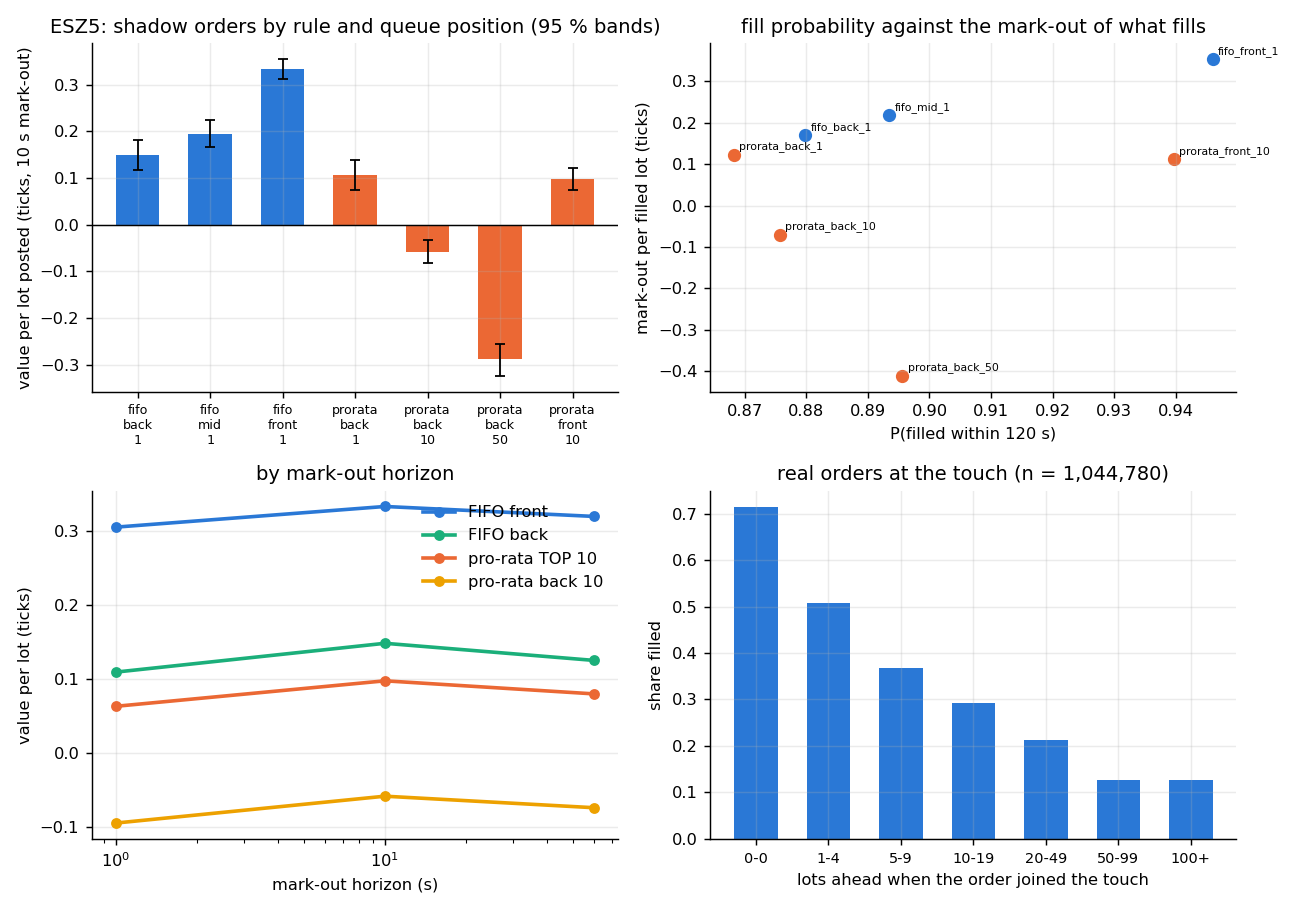

In [4]:
for sym, q in run['queue'].items():
    s = q['tau_10s']
    tab = pd.DataFrame(s['groups']).T[['rule', 'variant', 'size', 'n', 'p_any_fill', 'fill_share', 'median_time_to_fill_s', 'half_spread_per_filled_lot', 'markout_per_filled_lot', 'value_per_lot', 'ci']]
    display(tab)
    for k in ('queue_value_fifo', 'queue_value_fifo_mid', 'queue_value_prorata_top', 'prorata_size_effect', 'fifo_vs_prorata_back'):
        print(sym, k, s[k])
    display(Image(f'results/figures/queue_{sym}.png'))

Every real order that joined the touch, by the volume ahead of it: fill share, life, and the 10 s mark-out of the ones that filled.

In [6]:
for sym, q in run['queue'].items():
    ro = q['real_orders']
    print({k: v for k, v in ro.items() if k != 'by_ahead'})
    display(pd.DataFrame(ro['by_ahead']))

{'n_orders': 1044780, 'p_fill': 0.2692021286778078, 'p_cancel': 0.7284366086640249, 'median_life_s': 0.168182, 'median_life_filled_s': 0.490811, 'median_life_cancelled_s': 0.1226115, 'mean_size': 1.8159373265185015, 'share_one_lot': 0.6628074810007849}


,ahead_bucket,n,p_fill,median_life_s,mean_size,markout_10s
0,0-0,42980,0.713727,0.000524,2.155258,0.036900
1,1-4,86247,0.507229,0.020319,1.840702,0.042210
2,5-9,115888,0.367018,0.167721,1.733027,0.043732
3,10-19,191908,0.292374,0.221778,1.788951,0.042840
4,20-49,363514,0.212798,0.144605,1.798679,0.021692
5,50-99,224627,0.126129,0.311528,1.827705,0.019181
6,100+,19616,0.127702,0.434296,1.902478,0.020958


## 2. The book

Time-weighted spread and depth, event and trade rates by hour (UTC); the compiled replay rebuilds the book from every MBO event and the validation compares all ten levels with Databento's MBP-10 at every packet.

{'events': 3658972, 'trades': 153819, 'traded_lots': 493504, 'orders_added': 1430012, 'cancels': 1424501, 'modifies': 294477, 'spread_ticks_tw': 1.0450321688849458, 'touch_depth_tw': 24.258080543444354, 'touch_orders_tw': 15.275829607212053, 'share_time_one_tick': 0.9549689678870091, 'trade_size_mean': 3.2083422724110804, 'trade_size_p50': 1.0, 'trade_size_p99': 28.0, 'tick_value_usd': 12.5, 'span_hours': 15.999983894722222, 'start': '2025-09-22T00:00:00.009394+00:00', 'end': '2025-09-22T15:59:59.951415+00:00'}


,hour,spread_ticks,touch_depth,touch_orders,seconds,events,trades
0,0,1.076298,13.252163,10.003435,3599.995245,72810,3375
1,1,1.057258,13.326713,9.815123,3600.008331,59514,2738
2,2,1.040748,14.719445,9.938894,3600.000312,31022,1345
3,3,1.041639,17.461865,12.054969,3600.834036,30885,1433
4,4,1.078202,17.700444,11.339817,3599.949841,20841,1067
5,5,1.060176,15.371595,10.207648,3599.215411,29761,1393
6,6,1.081337,16.248186,11.236442,3599.988689,61822,3220
7,7,1.098990,16.105362,10.866264,3600.000438,176401,7147
8,8,1.033428,17.276398,11.664109,3600.004211,114844,4975
9,9,1.034483,14.059278,10.321693,3600.006856,93209,3516


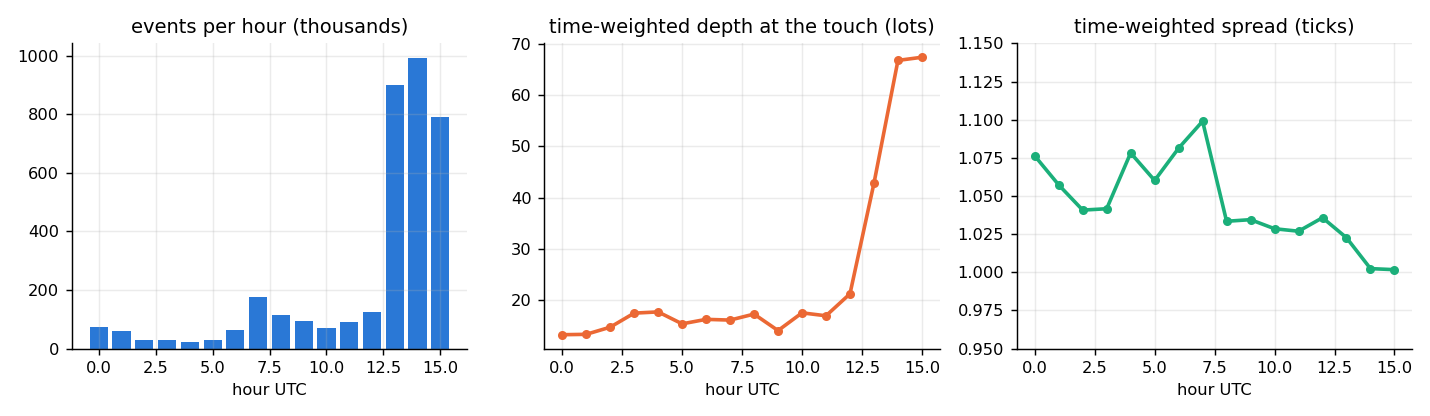

In [8]:
for sym, q in run['queue'].items():
    b = q['book']
    print({k: v for k, v in b.items() if k != 'by_hour'})
    display(pd.DataFrame(b['by_hour']))
    display(Image(f'results/figures/book_{sym}.png'))

## 3. The passive one-lot quoter

One lot each side at the touch, joined at the back, re-quoted when the touch moves, inventory hedged at the opposite touch when it reaches the limit. The attribution reconciles: cash + inventory at the closing mid = spread capture + inventory + hedge.

ESZ5 {'fills': 43972, 'passive_fills': 42946, 'hedges': 1026, 'lots': 48076.0, 'hedge_lots': 5130.0, 'ticks': {'spread_capture': 10189.5, 'inventory': -8455.5, 'hedge': -3480.0, 'total': -1746.0, 'identity_gap': 0.0}, 'usd': {'spread_capture': 127368.75, 'inventory': -105693.75, 'hedge': -43500.0, 'fees': -69710.2, 'total_after_fees': -91535.2}, 'per_passive_lot_usd': {'spread_capture': 2.9657884319843526, 'inventory': -2.461084850742793, 'hedge': -1.0128999208308107, 'fees': -1.6232058864620686, 'total_after_fees': -2.1314022260513203}, 'max_abs_inventory': 5.0, 'hours': 15.999796556944444, 'inv_end': -4.0, 'symbol': 'ESZ5'}


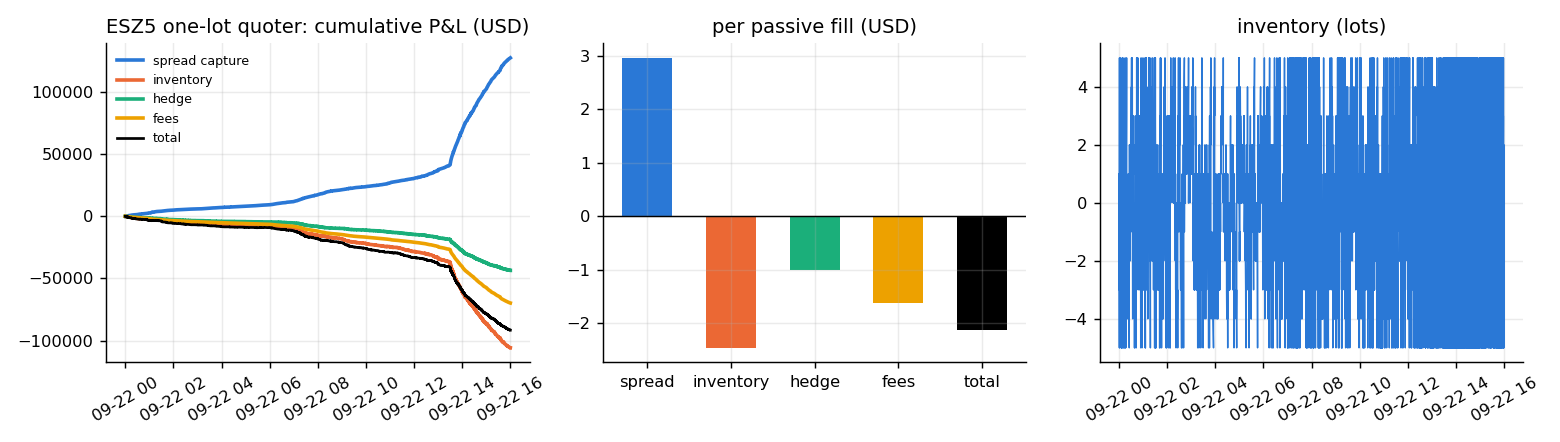

In [10]:
for sym, m in run.get('mm', {}).items():
    print(sym, {k: v for k, v in m.items() if k not in ('config',)})
display(Image('results/figures/mm.png'))

## 4. Rolls

Calendar spreads between listed contracts; implied financing of the equity spread against SOFR net of the dividend yield; the roll window; forty years of monthly energy rolls from EIA settlements.

,name,asset_class,contracts,pair_days,settlement_from,settlement_to,rolls_observed,exec_cost_usd,front_spread_usd_mean,share_contango
ES,E-mini S&P 500,equity,5,2000,2024-09-20,2026-09-18,1,4.15,2679.35,1.0
NQ,E-mini Nasdaq-100,equity,5,1005,2024-09-20,2026-09-18,1,3.4,4843.757046,0.960212
ZN,10-Year T-Note,rates,3,190,2025-12-19,2026-09-18,1,5.60625,-152.03373,0.0
ZB,30-Year T-Bond,rates,3,190,2025-12-19,2026-09-18,1,9.5125,-392.361111,0.0
ZT,2-Year T-Note,rates,3,176,2025-12-31,2026-09-18,1,5.60625,-98.345588,0.285714
SR3,Three-Month SOFR,rates,13,12,2026-09-18,2026-09-18,0,7.65,-812.492371,0.0
ZQ,30-Day Fed Funds,rates,18,8518,2024-09-20,2026-09-18,0,11.8175,-13.779416,0.314741
CL,WTI Crude Oil,energy,35,17035,2024-09-20,2026-09-18,1,8.2,-125.358422,0.39243
NG,Henry Hub Natural Gas,energy,36,17539,2024-09-20,2026-09-18,0,8.2,-99.800668,0.603586
GC,Gold,metals,14,3498,2024-09-20,2026-09-18,0,8.5,2837.644828,1.0


,root,near,far,roll_date,spread,spread_usd,spread_10bd_before,drift_usd,spread_sd_usd_10bd,volume_crossover,bd_crossover_to_roll,exec_cost_usd,richness_usd,richness_bp,roll_cost_long_usd
0,ES,ESU26,ESZ26,2026-09-11,67.750000,3387.500000,68.000000,-12.500000,36.857929,2026-09-14,-1,4.15000,871.157297,91.238393,3391.650000
1,NQ,NQU26,NQZ26,2026-09-11,297.250000,5945.000000,296.000000,25.000000,43.874822,2026-09-14,-1,3.40000,1262.419497,86.152903,5948.400000
2,ZN,ZNU26,ZNZ26,2026-08-27,-0.250000,-250.000000,-0.265625,15.625000,12.325166,2026-08-27,0,5.60625,NaN,NaN,-244.393750
3,ZB,ZBU26,ZBZ26,2026-08-27,-0.500000,-500.000000,-0.500000,0.000000,23.058275,2026-08-27,0,9.51250,NaN,NaN,-490.487500
4,ZT,ZTU26,ZTZ26,2026-08-27,-0.136719,-273.437500,-0.113281,-46.875000,12.242353,2026-08-27,0,5.60625,NaN,NaN,-267.831250
5,CL,CLV26,CLX26,2026-09-18,-4.220001,-4220.001221,-2.910004,-1309.997559,848.677179,2026-09-18,0,8.20000,NaN,NaN,-4211.801221


,mean,ci,n,sd
CL,37.860297,"[-47.855201698513945, 123.8480891719747]",471,946.765542
NG,726.326722,"[518.7702479338843, 941.7475206611572]",363,2093.899536


,richness_bp_mean,richness_bp_ci,richness_bp_p10_p90,implied_r_mean,sofr_mean,div_yield_mean,richness_usd_mean,days,from,to
ES,50.560352,"[43.25785707151625, 57.59988737344165]","[-27.659096186693265, 130.0548327266056]",0.042533,0.037477,0.010488,479.074348,252,2025-09-18,2026-09-18
NQ,39.432941,"[32.75233583406089, 46.36705759119808]","[-31.164404279738143, 129.05844936103784]",0.04142,0.037477,0.004443,545.42089,252,2025-09-18,2026-09-18


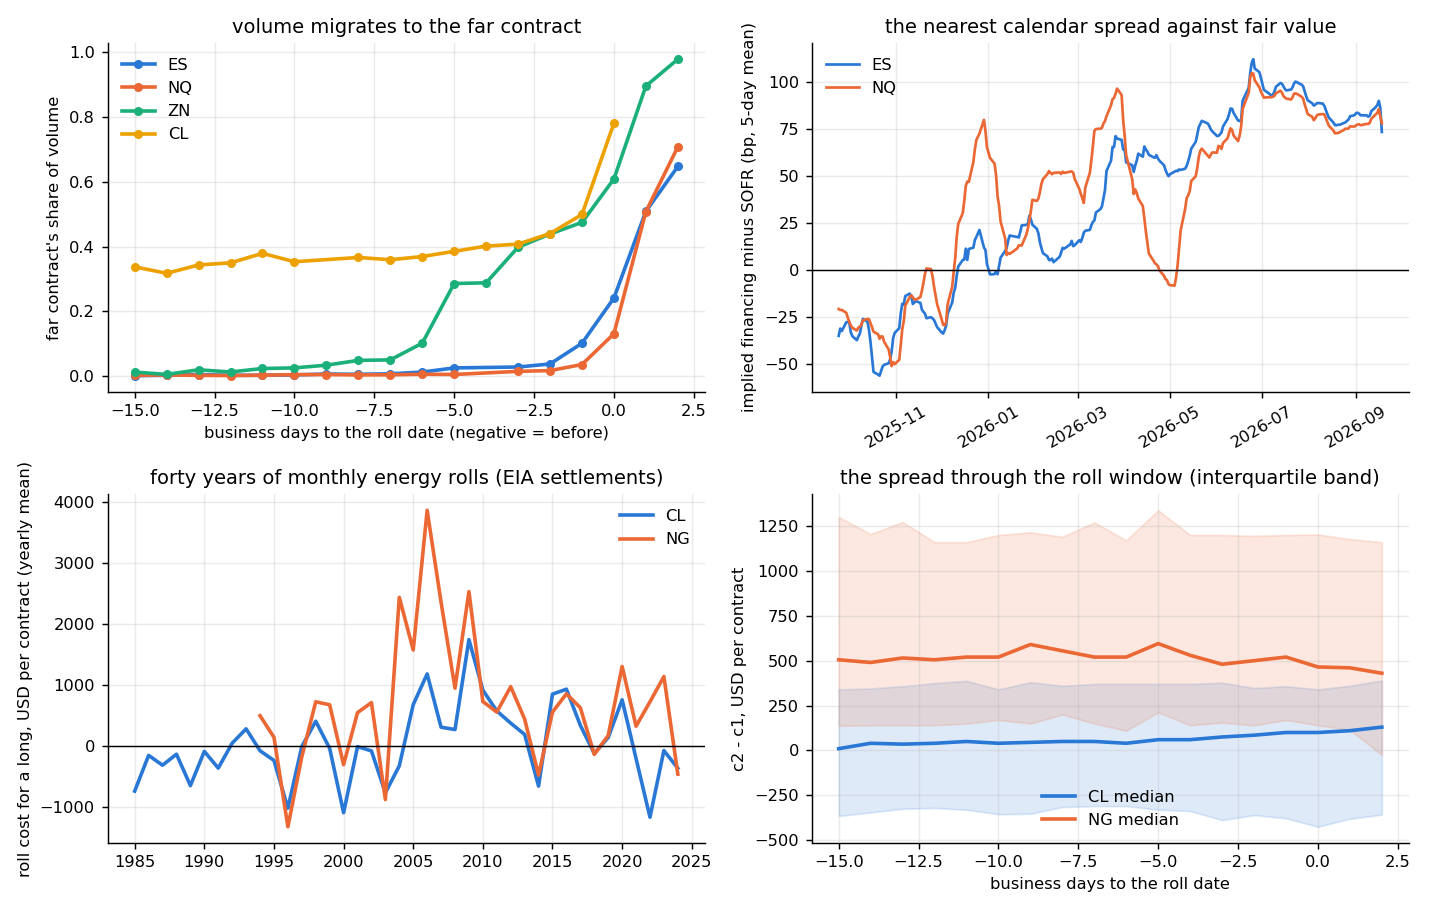

In [12]:
r = run['roll']
display(pd.DataFrame({k: {kk: vv for kk, vv in v.items() if not isinstance(vv, (dict, list))} for k, v in r.items()}).T)
ev = pd.concat([pd.DataFrame(v['events']) for v in r.values() if v.get('events')], ignore_index=True)
display(ev)
display(pd.DataFrame({k: v['eia']['roll_cost_long_usd'] for k, v in r.items() if 'eia' in v}).T)
display(pd.DataFrame({k: v['implied_financing'] for k, v in r.items() if 'implied_financing' in v}).T)
display(Image('results/figures/roll.png'))

## 5. The stated book

Settlement variation = price + roll exactly; execution at each roll (half a spread tick and two fees per contract); financing of the SPAN-style margin at SOFR; core and hedge halves.

{'from': '2026-08-19', 'to': '2026-09-18', 'days': 22, 'components_usd': {'variation': 42113.02795410156, 'price': 48713.02795410156, 'roll': -6600.0, 'execution': -1080.0, 'financing': -4563.7361388888885, 'total': 36469.29181521258}, 'identity_gap_usd': 0.0, 'avg_initial_margin_usd': 1449700.0, 'avg_notional_usd': 47893225.610767715, 'variation_daily_sd_usd': 96772.61382736664, 'worst_day_usd': -158949.99237060547, 'worst_day': '2026-09-04', 'best_day_usd': 173550.0457763672, 'max_drawdown_usd': -345563.28735069436, 'financing_share_of_gross_pnl': 0.002571897057886418}


,variation,price,roll,execution,rolls
CL,406000.14,406000.14,0.0,0.00,0.0
ES,-138500.00,-3000.00,-135500.0,-166.00,1.0
GC,2900.39,2900.39,0.0,0.00,0.0
NQ,-13600.00,-132500.00,118900.0,-68.00,1.0
ZB,33750.00,48750.00,-15000.0,-285.38,1.0
ZN,-248437.50,-273437.50,25000.0,-560.62,1.0


,variation,price,roll,execution
core,21963.03,132463.03,-110500.0,-726.62
hedge,20150.00,-83750.00,103900.0,-353.38


,date,root,code,qty,spread_paid,roll,execution
0,2026-09-14,ES,ESZ26,40,67.75,-135500.0,-166.000
1,2026-09-14,NQ,NQZ26,-20,297.25,118900.0,-68.000
2,2026-08-28,ZN,ZNZ26,100,-0.25,25000.0,-560.625
3,2026-08-28,ZB,ZBZ26,-30,-0.50,-15000.0,-285.375


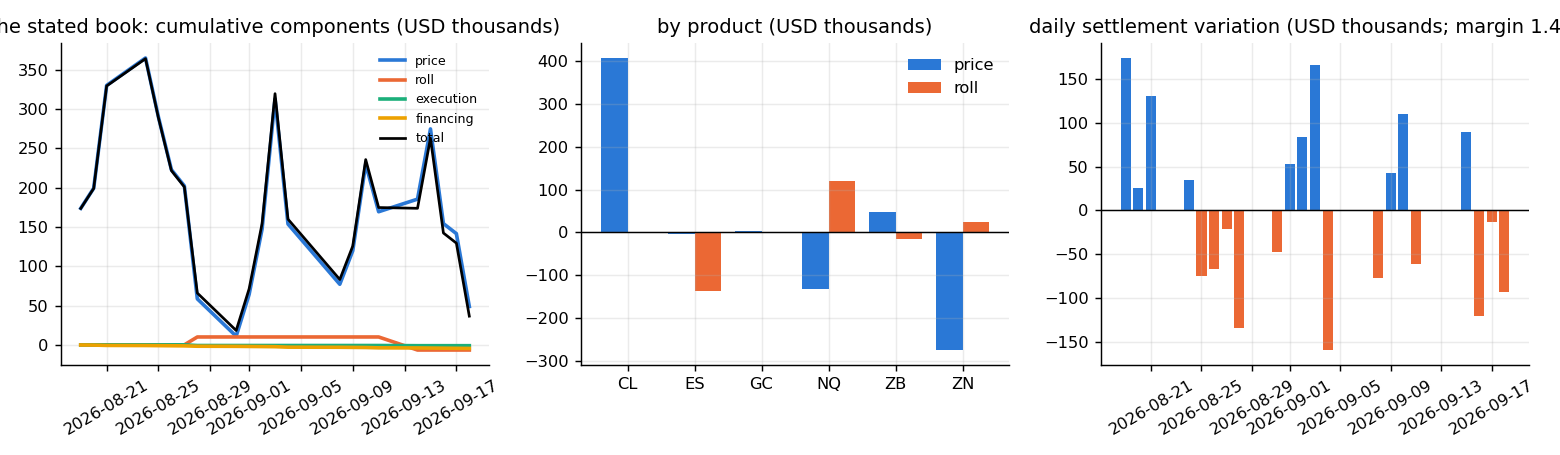

In [14]:
b = run['book']
print({k: v for k, v in b.items() if k not in ('positions', 'rolls', 'by_role_usd', 'by_root_usd')})
display(pd.DataFrame(b['by_root_usd']).T); display(pd.DataFrame(b['by_role_usd']).T); display(pd.DataFrame(b['rolls']))
display(Image('results/figures/book.png'))

## 6. The monitor

Fault days alternate with clean days; a fault is caught when an alert of its rule for its product arrives within the detection window.

{'fault_days': 20, 'clean_days': 20, 'injected': 120, 'caught': 116, 'detection_rate': 0.9666666666666667, 'median_ttd_s': 0.0, 'false_alerts_per_clean_day': 0.0, 'alerts_per_fault_day': 73.3}


,injected,caught,median_ttd_s,rules
fat_finger,10,10,0.0,[FAT_FINGER]
wrong_side,11,11,0.0,[POSITION_JUMP]
duplicate_fill,12,12,5.0,[DUPLICATE_FILL]
bad_price,13,13,0.0,[PRICE_BAND]
stale_feed,11,11,128.492455,[STALE_MARK]
missed_roll,11,11,0.0,"[DELIVERY_RISK, EXPIRY_RISK]"
margin_shock,13,13,9.456104,[MARGIN_CALL]
hedge_dropped,14,11,0.0,[PAIR_BROKEN]
limit_breach,11,11,0.0,[POSITION_LIMIT]
phantom_fill,8,8,13892.973668,[RECON_BREAK]


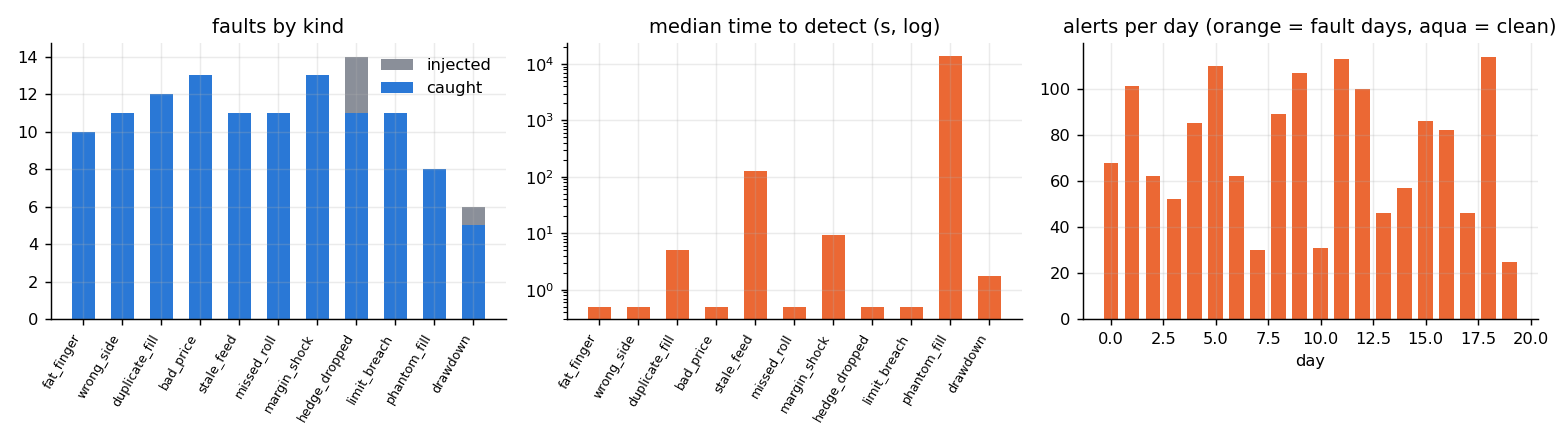

In [16]:
m = run['monitor']
print({k: v for k, v in m.items() if k not in ('by_kind', 'limits', 'clean_day_alerts_by_rule')})
display(pd.DataFrame(m['by_kind']).T)
display(Image('results/figures/monitor.png'))

## 7. The matching rules and SQL over the store

In [18]:
mt = run['matching']
display(pd.DataFrame(mt['rules']).T)
print(json.dumps(mt['implied'], indent=1)[:1200])
import duckdb
con = duckdb.connect(os.path.join(DER, 'futdesk.duckdb'), read_only=True)
for q in ["select rule, variant, size, count(*) n, avg(filled * 1.0 / size) fill_share from shadows_esz5 group by 1,2,3 order by 1,2,3",
          "select root, count(*) rolls, round(avg(roll_cost_long_usd)) mean_cost from roll_eia_events group by 1",
          "select rule, count(*) from monitor_alerts group by 1 order by 2 desc"]:
    try:
        display(con.execute(q).df())
    except Exception as e:
        print('no table:', str(e)[:80])
con.close()

{
 "before": {
  "leg1": {
   "bid": [
    1000,
    10
   ],
   "ask": [
    1002,
    10
   ],
   "bid_real": [
    1000,
    10
   ],
   "ask_real": [
    1002,
    10
   ]
  },
  "leg2": {
   "bid": [
    990,
    4
   ],
   "ask": [
    993,
    6
   ],
   "bid_real": [
    990,
    4
   ],
   "ask_real": [
    993,
    6
   ]
  },
  "spread": {
   "bid": [
    7,
    6
   ],
   "ask": [
    12,
    4
   ],
   "bid_real": [
    null,
    0
   ],
   "ask_real": [
    null,
    0
   ]
  }
 },
 "sell_2_spread_at_7": [
  {
   "taker_id": 6,
   "maker_id": -2,
   "price": 7,
   "qty": 2,
   "book": "spread",
   "via": "implied"
  }
 ],
 "leg_fills": [
  {
   "taker_id": -2,
   "maker_id": 1,
   "price": 1000,
   "qty": 2,
   "book": "leg1",
   "via": "implied-leg"
  },
  {
   "taker_id": -2,
   "maker_id": 4,
   "price": 993,
   "qty": 2,
   "book": "leg2",
   "via": "implied-leg"
  }
 ],
 "after": {
  "leg1": {
   "bid": [
    1000,
    8
   ],
   "ask": [
    1002,
    10
   ],
   "b

,1,2,3
FIFO,60.0,NaN,NaN
"pro-rata, 2-lot minimum, no TOP",35.0,16.0,9.0
Allocation: TOP (max 10) + pro-rata + FIFO leftover,38.0,14.0,8.0
split 40 % FIFO / 60 % pro-rata,43.0,11.0,6.0


,rule,variant,size,n,fill_share
0,0,0,1,57540,0.879788
1,0,1,1,57540,0.893431
2,0,2,1,57540,0.945951
3,1,0,1,57540,0.868283
4,1,0,10,57540,0.824993
5,1,0,50,57540,0.700755
6,1,2,10,57540,0.876783


,root,rolls,mean_cost
0,CL,471,38.0
1,NG,363,726.0


,rule,count_star()
0,MARGIN_CALL,504
1,MARGIN_USAGE,284
2,PAIR_BROKEN,282
3,EXPIRY_RISK,77
4,POSITION_LIMIT,73
5,DELIVERY_RISK,49
6,STALE_MARK,46
7,PNL_DRAWDOWN,39
8,PRICE_BAND,37
9,FAT_FINGER,31
